## Human labels vs slant estimator

In [2]:
from pathlib import Path
import sys
import pandas as pd
import asyncio

ROOT = Path("../")
sys.path.append(str(ROOT / "src"))

from classifier import inference
from data_fetcher import get_videos_metadata
from models import Video

/Users/gustavidunsloth/Documents/Data Science/YouTube Algorithm Audit/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-12-01 16:22:09 [INFO] Database: Building database...


Running on: mps with 8 threads


In [3]:
path = "../data/slant/human_labels/"
csv = [pd.read_csv(f) for f in Path(path).glob("results_2021*.csv")]
df = pd.concat(csv,ignore_index=True)

# filter out non ideological labels
df = df[df["label_name"] != "One or both of the videos is not ideological"]
df = df.rename(columns={"label_name": "human_label"})

In [4]:
# generate video objects with metadata

ids = pd.unique(pd.concat([df["bottom_video_id"], df["top_video_id"]], ignore_index=True))
vids = [Video(id=str(id)) for id in ids]
chunks = [vids[i:i+49] for i in range(0, len(vids), 49)]

print(ids)

async def get_videos():
    results = await asyncio.gather(*(get_videos_metadata(c) for c in chunks))
    return [v for sub in results for v in sub]

vids_metadata = await get_videos()
print(vids_metadata[:5])


['vipqI7SCgjA' 'q5Gr9SQmkfc' 'fyF1pepEpDE' ... '6ex9n959XhQ' '2ZabLF4R5Os'
 'A-SmKj3zCKU']
[Video(id='vipqI7SCgjA', slant=None, title='Trump Gets CLOBBERED By A Nurse', channel='The Damage Report', description='Donald Trump gets clobbered by a nurse. John Iadarola and Francesca Fiorentini react on The Damage Report. Follow The Damage Report on Facebook: https://www.facebook.com/TheDamageReportTYT/\n\nHelp build the Home of the Progressives http://tyt.com/JOIN\n\nSubscribe to The Damage Report YouTube channel: https://www.youtube.com/thedamagereport?sub_confirmation=1\n\nFollow The Damage Report on Twitter: https://twitter.com/TheDamageReport\n\nRead more here: https://www.mediaite.com/trump/what-do-i-know-im-not-a-doctor-trump-touts-unproven-coronavirus-drug-at-briefing/\n\n"President\xa0Donald Trump\xa0lambasted the governor of Illinois and pushed an unproven drug for coronavirus at the White House press briefing on Sunday.\n\nThe daily briefing was not expected to go forward, until T

In [5]:
# generate video slants
vids_metadata = inference.predict(vids_metadata)

KeyboardInterrupt: 

In [49]:
#save to file
rows = [
    {
        "video_id": v.id,
        "video_obj": v
    }
    for v in vids_metadata
]
vid_df = pd.DataFrame.from_records(rows)
vid_df.to_pickle("../data/slant/human_labels/vid_metadata.pkl")

In [7]:
vid_df = pd.read_pickle("../data/slant/human_labels/vid_metadata.pkl")

df_merged = (
    df
    .merge(vid_df, how="left", left_on="top_video_id", right_on="video_id")
    .rename(columns={"video_obj": "top_video_obj"})
    .drop(columns=["video_id"])
    .merge(vid_df, how="left", left_on="bottom_video_id", right_on="video_id")
    .rename(columns={"video_obj": "bottom_video_obj"})
    .drop(columns=["video_id"])
)
df_merged = df_merged[df_merged["top_video_obj"].notna()]
df_merged = df_merged[df_merged["bottom_video_obj"].notna()]

# slant labels
df_merged["top_slant_pred"] = [vid.slant for vid in df_merged["top_video_obj"].to_list()]
df_merged["bottom_slant_pred"] = [vid.slant for vid in df_merged["bottom_video_obj"].to_list()]

label_map = {
    "The top video is more right leaning than the bottom video": "top",
    "The top video is more left leaning than the bottom video": "top",
    "The bottom video is more left leaning than the top video": "bot",
    "The bottom video is more right leaning than the top video": "bot"
}

df_merged["human_label"] = df_merged["human_label"].map(label_map)

In [ ]:
#split df
df_con = df_merged[df_merged["category_name"] == "Indicate which video is more conservative"]
df_lib = df_merged[df_merged["category_name"] == "Indicate which video is more liberal"]

def label_pred(row, con : bool):
    if con:
        if row["top_slant_pred"] > row["bottom_slant_pred"]: return "top"
        else: return "bot"
    else:
        if row["top_slant_pred"] > row["bottom_slant_pred"]: return "bot"
        else: return "top"

df_lib["pred_label"] = df_lib.apply(label_pred, axis=1, args=(False,))
df_con["pred_label"] = df_con.apply(label_pred, axis=1, args=(True,))



final_df = pd.concat([df_lib, df_con], ignore_index=True)
final_df["agree"] = final_df.apply(lambda row: True if row["pred_label"] == row["human_label"] else False, axis=1)
final_df["dist"] = final_df.apply(lambda row: abs(row["top_slant_pred"] - row["bottom_slant_pred"]), axis=1)


/var/folders/p6/8cdyrdjx0bb9nc27_9f01gpw0000gn/T/ipykernel_1488/2875744663.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_lib["pred_label"] = df_lib.apply(label_pred, axis=1, args=(False,))
/var/folders/p6/8cdyrdjx0bb9nc27_9f01gpw0000gn/T/ipykernel_1488/2875744663.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_con["pred_label"] = df_con.apply(label_pred, axis=1, args=(True,))


In [19]:
df_con

,unique_ID,category_name,human_label,coder_id,label_timestamp,top_video_id,bottom_video_id,text,missing,top_video_obj,bottom_video_obj,top_slant_pred,bottom_slant_pred,pred_label
0,724,Indicate which video is more conservative,top,9,1629731881,uedm-W2hyX0,vipqI7SCgjA,A video praising the sanction on Maduro and de...,0,"Video ID: uedm-W2hyX0, video slant: -0.7966040...","Video ID: vipqI7SCgjA, video slant: -0.7771024...",-0.796604,-0.777102,bot
1,817,Indicate which video is more conservative,bot,9,1629732017,J5rX5f0HcjQ,q5Gr9SQmkfc,Video showing congress has forget to pass a la...,0,"Video ID: J5rX5f0HcjQ, video slant: -0.8306070...","Video ID: q5Gr9SQmkfc, video slant: 0.67766189...",-0.830607,0.677662,bot
2,996,Indicate which video is more conservative,top,9,1629732048,4LZ3P1sv9jE,fyF1pepEpDE,Showing the Donald Trump rally in 2016 electio...,0,"Video ID: 4LZ3P1sv9jE, video slant: -0.8153780...","Video ID: fyF1pepEpDE, video slant: 0.04849278...",-0.815378,0.048493,bot
37,1016,Indicate which video is more conservative,bot,7,1630797634,MZOyevnbxUQ,4Q4O5ztz92o,interview with a Ugandan transgender activist,0,"Video ID: MZOyevnbxUQ, video slant: -0.4255728...","Video ID: 4Q4O5ztz92o, video slant: 0.00103783...",-0.425573,0.001038,bot
38,1017,Indicate which video is more conservative,bot,7,1630801208,MZOyevnbxUQ,Q3N-PWW5-AM,discussing brexit.,0,"Video ID: MZOyevnbxUQ, video slant: -0.4255728...","Video ID: Q3N-PWW5-AM, video slant: 0.33795845...",-0.425573,0.337958,bot
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5156,1035,Indicate which video is more conservative,bot,9,1632108389,bacceMqv7-Q,12U-mWINFM8,Video that says man are discriminated against ...,0,"Video ID: bacceMqv7-Q, video slant: -0.8133974...","Video ID: 12U-mWINFM8, video slant: -0.4515485...",-0.813397,-0.451549,bot
5157,1048,Indicate which video is more conservative,bot,9,1632108511,xAKPNNgYrcs,nGmq6tv2wvU,Video says democrats no longer want Biden beca...,0,"Video ID: xAKPNNgYrcs, video slant: -0.7633939...","Video ID: nGmq6tv2wvU, video slant: -0.8585730...",-0.763394,-0.858573,top
5158,1058,Indicate which video is more conservative,bot,9,1632108610,cWMmRmEpUmE,CjhsLq3-ZWE,Ari Shaffir argues for violence to revolutioni...,0,"Video ID: cWMmRmEpUmE, video slant: -0.6886731...","Video ID: CjhsLq3-ZWE, video slant: -0.6870213...",-0.688673,-0.687021,bot
5159,1080,Indicate which video is more conservative,top,9,1632108691,L7hPoDU_nPk,glHmdBEgbYk,An Indian farmer protest the Modi's government...,0,"Video ID: L7hPoDU_nPk, video slant: 0.03582572...","Video ID: glHmdBEgbYk, video slant: -0.6342743...",0.035826,-0.634274,top


In [86]:
final_df.to_pickle("../data/slant/human_labels/labels.pkl")

In [9]:
final_df

,unique_ID,category_name,human_label,coder_id,label_timestamp,top_video_id,bottom_video_id,text,missing,top_video_obj,bottom_video_obj,top_slant_pred,bottom_slant_pred,pred_label,agree,dist
0,1025,Indicate which video is more liberal,bot,8,1630462269,5HK1hFUD_d4,QPVA8HH7l1w,Bernie Sanders criticizes Republicans,0,"Video ID: 5HK1hFUD_d4, video slant: 0.00277519...","Video ID: QPVA8HH7l1w, video slant: -0.8106010...",0.002775,-0.810601,bot,True,0.813376
1,1112,Indicate which video is more liberal,top,8,1630462309,npAKW_HPnq8,AK4_ogsh0Po,AOC endorsing Bernie Sanders for President,0,"Video ID: npAKW_HPnq8, video slant: -0.7649744...","Video ID: AK4_ogsh0Po, video slant: -0.4801479...",-0.764974,-0.480148,top,True,0.284827
2,1029,Indicate which video is more liberal,bot,8,1630467371,Ib1nTc7859Y,_TgcOISrlqE,Questioning the efficacy of 'antifa violence',0,"Video ID: Ib1nTc7859Y, video slant: -0.4181954...","Video ID: _TgcOISrlqE, video slant: -0.2225410...",-0.418195,-0.222541,top,False,0.195654
3,1061,Indicate which video is more liberal,bot,8,1630467386,KC-JiXnQSUA,JkxW7ecWl-o,Satirical video mocking Trump,0,"Video ID: KC-JiXnQSUA, video slant: -0.8150068...","Video ID: JkxW7ecWl-o, video slant: -0.7883945...",-0.815007,-0.788395,top,False,0.026612
4,1070,Indicate which video is more liberal,bot,8,1630467421,SvjTeuSKTW0,iEWqEtnLLEo,Video about Jill Stein,0,"Video ID: SvjTeuSKTW0, video slant: -0.2916723...","Video ID: iEWqEtnLLEo, video slant: 0.24039983...",-0.291672,0.240400,top,False,0.532072
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4221,1035,Indicate which video is more conservative,bot,9,1632108389,bacceMqv7-Q,12U-mWINFM8,Video that says man are discriminated against ...,0,"Video ID: bacceMqv7-Q, video slant: -0.8133974...","Video ID: 12U-mWINFM8, video slant: -0.4515485...",-0.813397,-0.451549,bot,True,0.361849
4222,1048,Indicate which video is more conservative,bot,9,1632108511,xAKPNNgYrcs,nGmq6tv2wvU,Video says democrats no longer want Biden beca...,0,"Video ID: xAKPNNgYrcs, video slant: -0.7633939...","Video ID: nGmq6tv2wvU, video slant: -0.8585730...",-0.763394,-0.858573,top,False,0.095179
4223,1058,Indicate which video is more conservative,bot,9,1632108610,cWMmRmEpUmE,CjhsLq3-ZWE,Ari Shaffir argues for violence to revolutioni...,0,"Video ID: cWMmRmEpUmE, video slant: -0.6886731...","Video ID: CjhsLq3-ZWE, video slant: -0.6870213...",-0.688673,-0.687021,bot,True,0.001652
4224,1080,Indicate which video is more conservative,top,9,1632108691,L7hPoDU_nPk,glHmdBEgbYk,An Indian farmer protest the Modi's government...,0,"Video ID: L7hPoDU_nPk, video slant: 0.03582572...","Video ID: glHmdBEgbYk, video slant: -0.6342743...",0.035826,-0.634274,top,True,0.670100


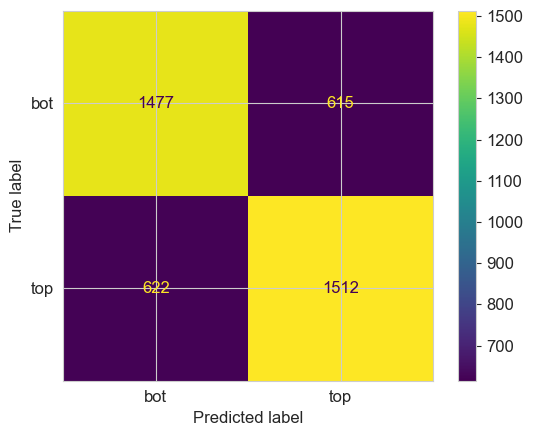

In [10]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(final_df["human_label"], final_df["pred_label"])

In [11]:
from sklearn.metrics import classification_report

print(classification_report(final_df["human_label"], final_df["pred_label"]))

              precision    recall  f1-score   support

         bot       0.70      0.71      0.70      2092
         top       0.71      0.71      0.71      2134

    accuracy                           0.71      4226
   macro avg       0.71      0.71      0.71      4226
weighted avg       0.71      0.71      0.71      4226



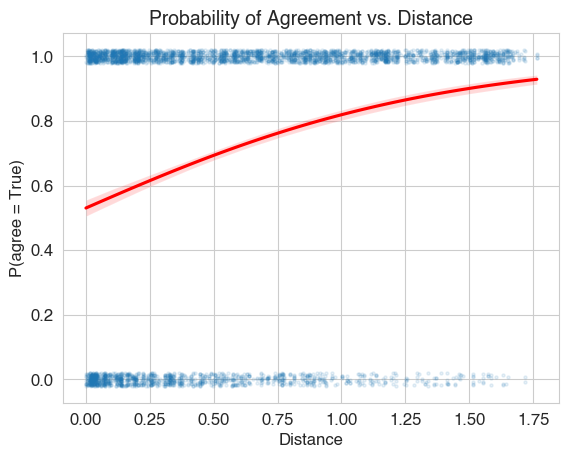

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

# Set global font to Helvetica
mpl.rcParams["font.family"] = "sans-serif"
mpl.rcParams["font.sans-serif"] = ["Helvetica"]

plt.figure(figsize=(5, 5))  # 1:1 aspect ratio

sns.regplot(
    data=final_df,
    x="dist",
    y="agree",
    logistic=True,
    ci=95,
    scatter_kws={"s": 5, "alpha": 0.1},
    line_kws={"color": "red"},
    y_jitter=0.02,
)

plt.title("Probability of Agreement vs. Distance")
plt.ylabel("P(agree = True)")
plt.xlabel("Distance")
plt.show()

In [14]:
import statsmodels.api as sm
import numpy as np

# Prepare data
X = final_df["dist"]
y = final_df["agree"].astype(int)

# Add constant for intercept
X = sm.add_constant(X)

# Fit logistic regression
model = sm.Logit(y, X)
result = model.fit()

print(result.summary())


Optimization terminated successfully.
         Current function value: 0.565204
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                  agree   No. Observations:                 4226
Model:                          Logit   Df Residuals:                     4224
Method:                           MLE   Df Model:                            1
Date:                Mon, 01 Dec 2025   Pseudo R-squ.:                 0.06510
Time:                        16:25:34   Log-Likelihood:                -2388.6
converged:                       True   LL-Null:                       -2554.9
Covariance Type:            nonrobust   LLR p-value:                 2.542e-74
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1225      0.053      2.321      0.020       0.019       0.226
dist           1.3894      0.

In [16]:
bins = [0, 0.25, 0.5, 1.0, 1.5, 2.0]
final_df["Score distance"] = pd.cut(final_df["dist"], bins=bins)

table = (
    final_df.groupby("Score distance")
    .agg({"agree": "mean"})
    .rename(columns={"agree": "% Agreement"})
)

table["% Agreement"] = (table["% Agreement"] * 100).round(2)

table

/var/folders/p6/8cdyrdjx0bb9nc27_9f01gpw0000gn/T/ipykernel_1488/2212099169.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  final_df.groupby("Score distance")


,% Agreement
Score distance,
"(0.0, 0.25]",58.19
"(0.25, 0.5]",62.26
"(0.5, 1.0]",75.70
"(1.0, 1.5]",85.81
"(1.5, 2.0]",91.72
